# Mutual Fund Analytics Platform

## Performance Analytics

This notebook computes performance metrics such as Daily Returns, CAGR, Sharpe Ratio, Sortino Ratio, and Maximum Drawdown for mutual fund schemes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


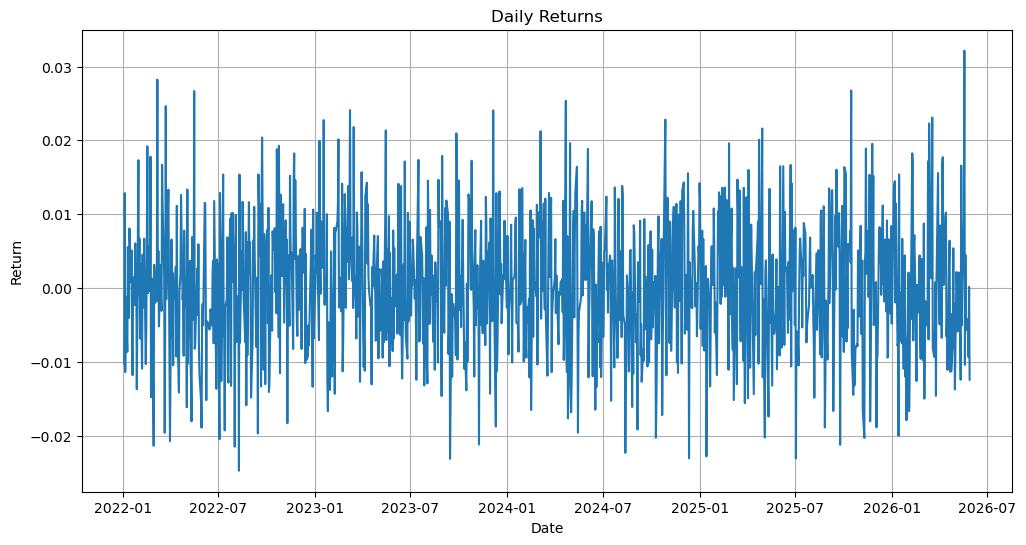

In [5]:
sample = nav[
    nav["amfi_code"] == nav["amfi_code"].iloc[0]
]

plt.figure(figsize=(12,6))

plt.plot(
    sample["date"],
    sample["daily_return"]
)

plt.title("Daily Returns")

plt.xlabel("Date")
plt.ylabel("Return")

plt.grid(True)

plt.show()

### Observation

- Daily returns fluctuate around zero.
- Positive values indicate gains, while negative values indicate losses.
- Short-term volatility is visible throughout the time series.

In [6]:
cagr = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
    ) / 365.25

    value = (
        (end_nav / start_nav) ** (1 / years) - 1
    ) * 100

    cagr.append([code, value])

cagr_df = pd.DataFrame(
    cagr,
    columns=["amfi_code", "CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


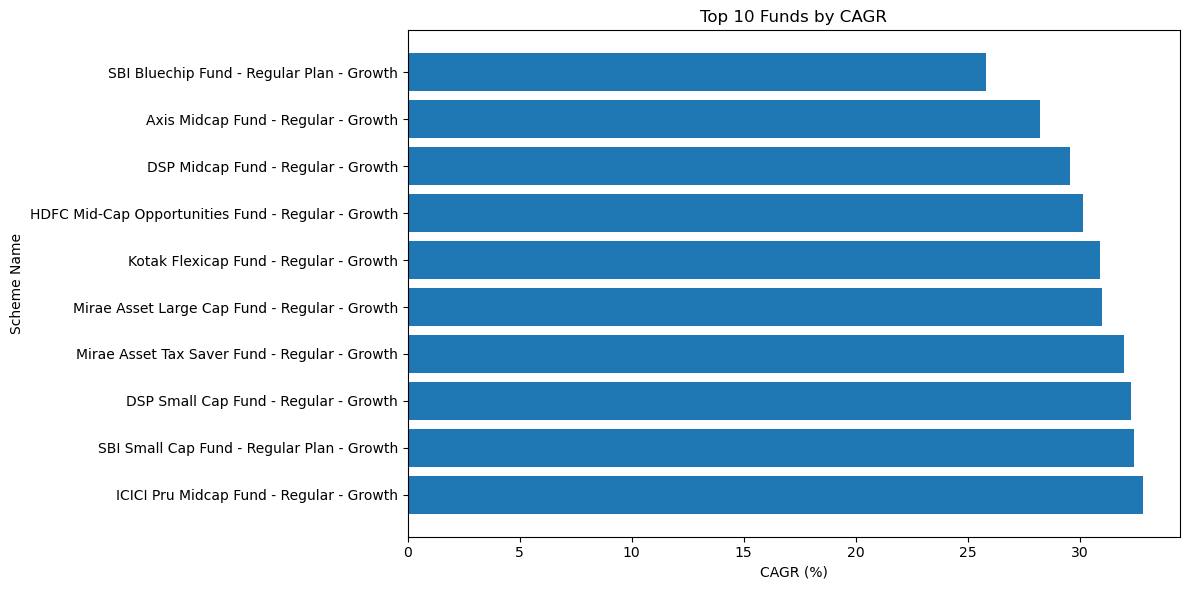

In [8]:
# Load fund master data
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Merge with CAGR data
cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Top 10 funds
top = cagr_df.sort_values(
    by="CAGR",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top["scheme_name"],
    top["CAGR"]
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("CAGR (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

## Sharpe Ratio Analysis

In [9]:
risk_free_rate = 0.065  # 6.5%

sharpe_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252
        annual_std = returns.std() * np.sqrt(252)

        sharpe = (annual_return - risk_free_rate) / annual_std

        sharpe_list.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "Sharpe_Ratio"]
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


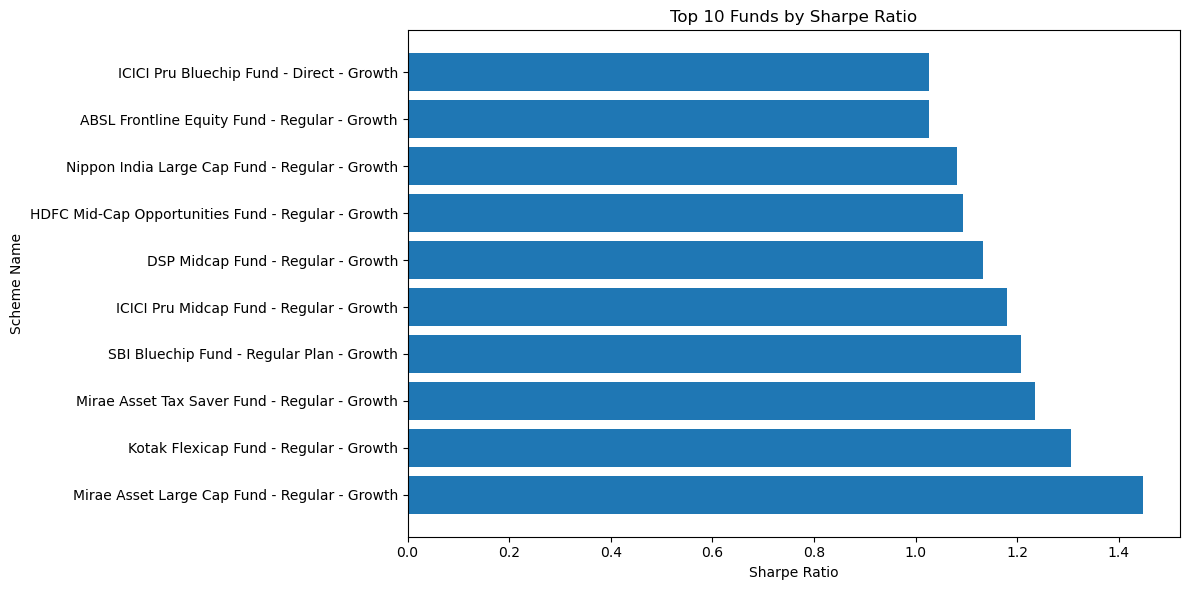

In [11]:
# Load fund master data
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Merge Sharpe ratio data with scheme names
sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Get Top 10 funds by Sharpe Ratio
top_sharpe = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(12, 6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["Sharpe_Ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

### Observation

- Higher Sharpe Ratios indicate better risk-adjusted returns.
- Funds with higher values have delivered stronger returns relative to their volatility.

## Sortino Ratio Analysis

In [17]:
sortino_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    returns = df["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    if len(downside_returns) > 0:

        annual_return = returns.mean() * 252
        downside_std = downside_returns.std() * np.sqrt(252)

        sortino = (annual_return - risk_free_rate) / downside_std

        sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "Sortino_Ratio"]
)
sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_df.head()


,amfi_code,Sortino_Ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


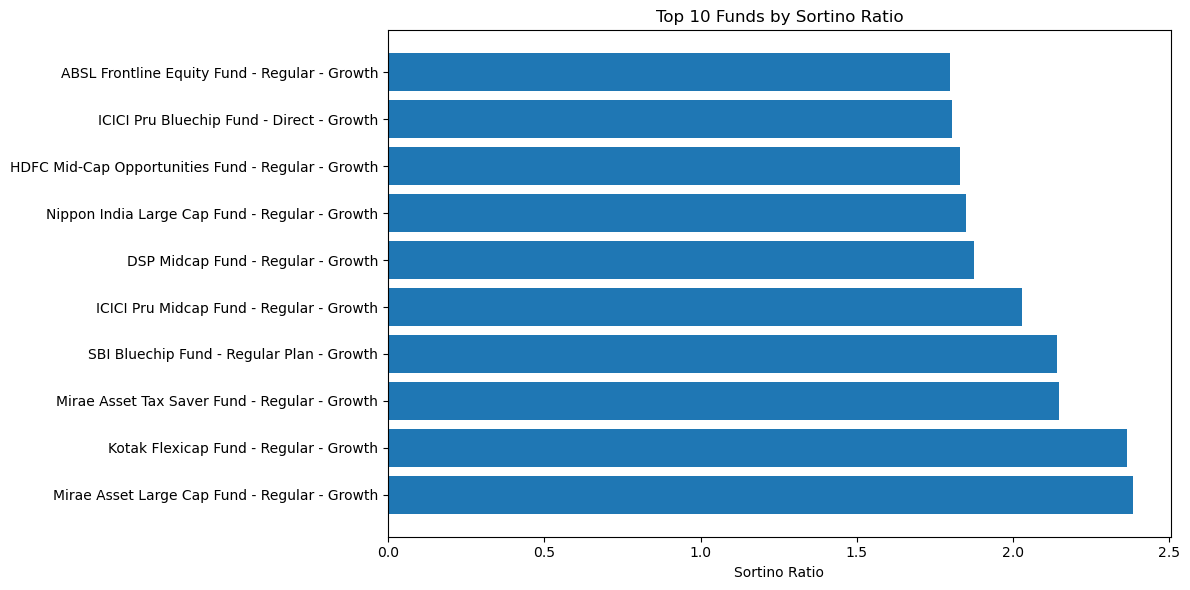

In [22]:
top_sortino = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_sortino["scheme_name"],
    top_sortino["Sortino_Ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")

plt.tight_layout()
plt.show()

## Maximum Drawdown Analysis

In [19]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    running_max = df["nav"].cummax()

    drawdown = (df["nav"] / running_max) - 1

    max_dd = drawdown.min()

    drawdown_list.append([code, max_dd * 100])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "Max_Drawdown"]
)
drawdown_df = drawdown_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown_df.head()

drawdown_df.head()

,amfi_code,Max_Drawdown,scheme_name
0,100016,-24.734441,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-4.308264,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-16.217209,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-11.291596,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-35.446916,ABSL Small Cap Fund - Regular - Growth


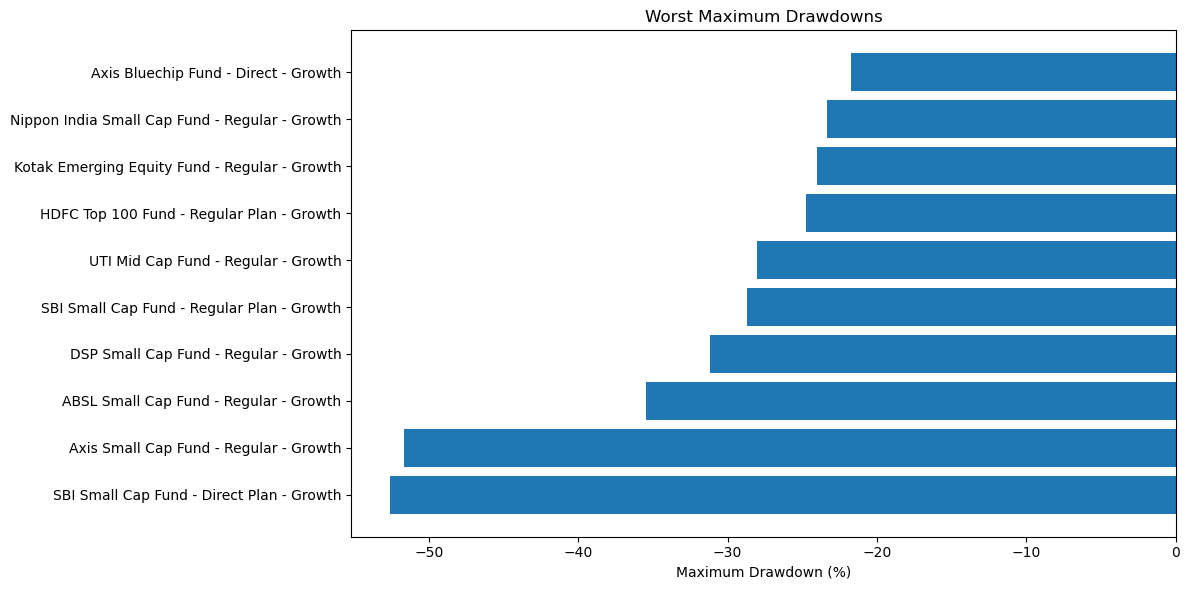

In [24]:
worst = drawdown_df.sort_values(
    by="Max_Drawdown"
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    worst["scheme_name"],
    worst["Max_Drawdown"]
)

plt.title("Worst Maximum Drawdowns")
plt.xlabel("Maximum Drawdown (%)")

plt.tight_layout()
plt.show()


### Observation

- Maximum Drawdown measures the largest decline from a previous peak NAV.
- Funds with larger negative drawdowns experienced greater historical losses.
- Lower drawdown values generally indicate better downside protection.

In [25]:
cagr_df.to_csv("../data/processed/cagr_report.csv", index=False)

sharpe_df.to_csv("../data/processed/sharpe_report.csv", index=False)

sortino_df.to_csv("../data/processed/sortino_report.csv", index=False)

drawdown_df.to_csv("../data/processed/max_drawdown_report.csv", index=False)

print("Reports saved successfully!")

Reports saved successfully!
